In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Problem Understanding

**To identify key factors influencing loan approval decisions**

In [14]:
#Load the data

df = pd.read_csv(r"D:\New folder (2)\Documents\New folder\loandata.csv")

#### Data Understanding

In [18]:
#Top 10 data points

df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001722,Male,Yes,0,Graduate,No,150,1800.0,135.0,360.0,1.0,Rural,N
1,LP002502,Female,Yes,2,Not Graduate,NaN,210,2917.0,98.0,360.0,1.0,Semiurban,Y
2,LP002949,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N
3,LP002603,Female,No,0,Graduate,No,645,3683.0,113.0,480.0,1.0,Rural,Y
4,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
5,LP001259,Male,Yes,1,Graduate,Yes,1000,3022.0,110.0,360.0,1.0,Urban,N
6,LP002345,Male,Yes,0,Graduate,No,1025,2773.0,112.0,360.0,1.0,Rural,Y
7,LP002717,Male,Yes,0,Graduate,No,1025,5500.0,216.0,360.0,NaN,Rural,Y
8,LP001030,Male,Yes,2,Graduate,No,1299,1086.0,17.0,120.0,1.0,Urban,Y
9,LP001267,Female,Yes,2,Graduate,No,1378,1881.0,167.0,360.0,1.0,Urban,N


In [20]:
#Structure of data (types, nulls, size)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [26]:
#Statistics of data (mean, spread, range)

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [30]:
#Checking missing values

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Observations

- **Our data consists of 8 categorical and 5 Numerical( 1 Int, 4 float)**
- **Null values present in the data**
- **Cleaning is necessary to prevent the improper insights**
- **Outliers present in the data**

**Now we can observe there are null values and outliers present in the dataset but before we clean the data we are going to do the analysis on the uncleaned data to verify the robustness of the data after cleaning**

## EDA(Exploratory Data Analysis)

**Do Demographic factors affect Loan approval?**

In [119]:
df.groupby('Gender')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Gender,,
Female,0.330357,0.669643
Male,0.306748,0.693252


**Insight**

Gender has minimal impact considering the loan approvals and rejections

**Does location affect Loan approval?**

In [49]:
df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Property_Area,,
Rural,0.385475,0.614525
Semiurban,0.231760,0.768240
Urban,0.341584,0.658416


**Insight**

Semiurban areas got the most approved

**Does Credit history affect Loan approval?**

In [58]:
df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.204211,0.795789


**Insight**

People with positive credit history has got the more approvals which shows the strong separation so that makes the Credit history the key factor

**Does income influence loan amount**

In [69]:
df.groupby('Education')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Education,,
Graduate,0.291667,0.708333
Not Graduate,0.388060,0.611940


In [67]:
df.groupby('Education')['ApplicantIncome'].mean()

Education
Graduate        5857.433333
Not Graduate    3777.283582
Name: ApplicantIncome, dtype: float64

**Grduates show slightly higher loan approval rates compared to the non-graduates. This may partialy explained by higher average incomes among graduates, which could improve their creditworthiness**

## Visualization

<Axes: xlabel='Gender', ylabel='count'>

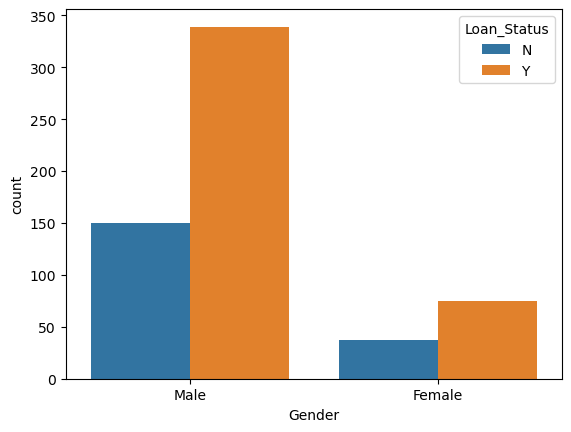

In [79]:
sns.countplot(x='Gender',hue='Loan_Status',data = df)

<Axes: xlabel='Property_Area', ylabel='count'>

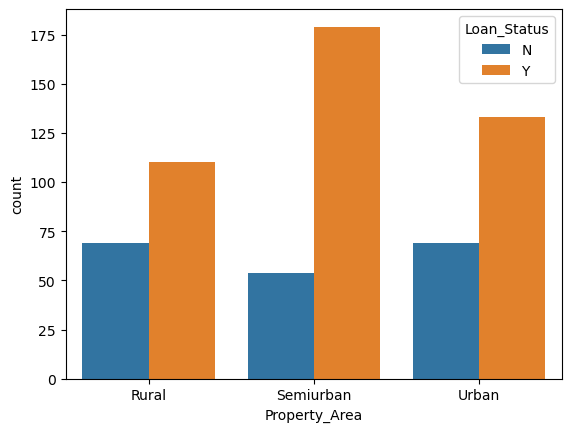

In [83]:
sns.countplot(x='Property_Area',hue='Loan_Status',data=df)

<Axes: xlabel='Credit_History', ylabel='count'>

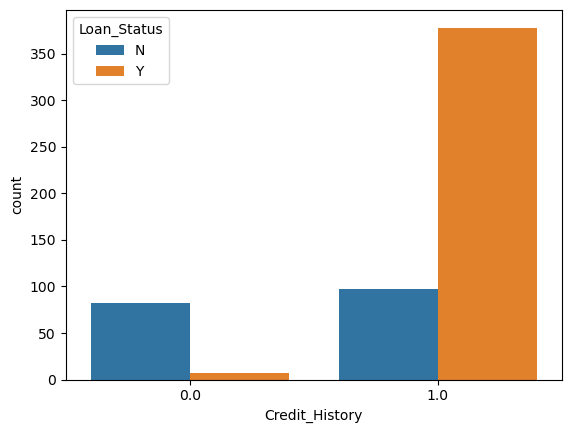

In [87]:
sns.countplot(x='Credit_History',hue='Loan_Status',data=df)

**We can clearly observed the Credit History showing the big difference in loan approvals which makes it the key factor**

### Data Cleaning

I created a backup of the original dataset to ensure reproducibility and to compare insights before and after preprocessing, which helps validate that data cleaning improves data quality without distorting key patterns.

In [90]:
#Before cleaning the data just getting the summary of the data

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [114]:
#Checking the skewness of the numerical data to decide whether to fill Mean or Median
#(We will fill Mean if the distribution is normal
# and Median if the distribution is not normal)

print(df['LoanAmount'].skew()) #Postitvely skewed
print(df['Loan_Amount_Term'].skew()) # Negatively skewed

2.6775516792560583
-2.362414124216269


In [116]:
#Finding the missing values, distribution and data imbalance

print(df['Gender'].value_counts(dropna=False))
print(df['Married'].value_counts(dropna=False))
print(df['Dependents'].value_counts(dropna=False))
print(df['Self_Employed'].value_counts(dropna=False))
print(df['Credit_History'].value_counts(dropna=False))

Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64
Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64


**Missing values in categorical variables were handled using mode, while numerical variables were imputed using median, especially for skewed distributions to reduce the impact of outliers**

In [147]:
df = df.fillna({
    'Gender':df['Gender'].mode()[0],
    'Married':df['Married'].mode()[0],
    'Dependents':df['Dependents'].mode()[0],
    'Self_Employed':df['Self_Employed'].mode()[0],
    'LoanAmount':df['LoanAmount'].median(),
    'Loan_Amount_Term':df['Loan_Amount_Term'].median(),
    'Credit_History':df['Credit_History'].mode()[0]
    
})

In [151]:
#After cleaning the data

df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [157]:
df['Gender'].value_counts(normalize=True)

Gender
Male      0.81759
Female    0.18241
Name: proportion, dtype: float64

In [159]:
df['Self_Employed'].value_counts(normalize=True)

Self_Employed
No     0.86645
Yes    0.13355
Name: proportion, dtype: float64

In [161]:
df['LoanAmount'].describe()

count    614.000000
mean     145.752443
std       84.107233
min        9.000000
25%      100.250000
50%      128.000000
75%      164.750000
max      700.000000
Name: LoanAmount, dtype: float64

In [163]:
df['LoanAmount'].skew()

2.7430527488208916

**Finding the Outliers**

<Axes: xlabel='LoanAmount'>

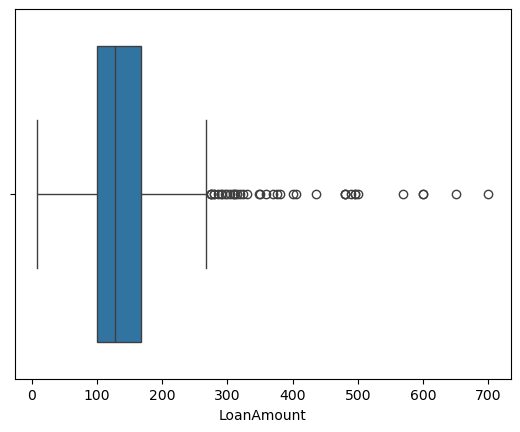

In [133]:
sns.boxplot(x=df['LoanAmount'])

In [165]:
df['LoanAmount_log'] = np.log(df['LoanAmount'])

In [187]:
df[['LoanAmount_log','ApplicantIncome','CoapplicantIncome']].skew()

LoanAmount_log      -0.195355
ApplicantIncome      6.539513
CoapplicantIncome    7.491531
dtype: float64

In [175]:
df['ApplicantIncome_log'] = np.log(df['LoanAmount']+1)

In [179]:
df['CoapplicantIncome_log'] = np.log(df['CoapplicantIncome']+1)

In [183]:
df[['LoanAmount_log','ApplicantIncome_log','CoapplicantIncome_log']].skew()

LoanAmount_log          -0.195355
ApplicantIncome_log     -0.151578
CoapplicantIncome_log   -0.173073
dtype: float64

### 📉 Outlier Handling

Outliers were identified in numerical features such as LoanAmount and income variables. Since these represent valid financial values, they were not removed. Instead, their impact was reduced using median imputation and log transformation.**

Log transformed versions of skewed numerical features were created as a separte columns to preserve the original data while enabling better analysis and modeling

In [189]:
df.groupby('Gender')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Gender,,
Female,0.330357,0.669643
Male,0.308765,0.691235


In [191]:
df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Property_Area,,
Rural,0.385475,0.614525
Semiurban,0.231760,0.768240
Urban,0.341584,0.658416


In [193]:
df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).unstack()

Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.209524,0.790476


### Comparison Before and After Cleaning

The analysis was performed on both raw and cleaned datasets to validate the stability of insights.

* **Gender:** Approval rates remained nearly unchanged, indicating minimal impact of missing values.
* **Credit_History:** Strong influence persisted, confirming it as the most important feature.
* **Property_Area:** Minor variations observed, but overall trend remained consistent.

This confirms that the dataset patterns are robust and not significantly affected by missing or inconsistent data.


### 🧠 Final Insights

* Credit History is the most significant factor influencing loan approval
* Gender has minimal impact on approval decisions
* Income and Loan Amount play supporting roles
* Data cleaning had minimal impact on overall insights, confirming reliability

These findings suggest that financial behavior indicators are more important than demographic attributes in loan approval decisions.
